# Exploratory Data Analysis

In [22]:
# IMPORTING LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
import squarify

In [23]:
# LOAD DATA
DATA_DIR = "../data/raw/raw_data.csv"
df = pd.read_csv(DATA_DIR)

In [24]:
# SHOW FIRST 5 ROWS
df.head(5)

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


## FEATURE TYPES

In [25]:
df.dtypes

Elevation                             int64
Aspect                                int64
Slope                                 int64
Horizontal_Distance_To_Hydrology      int64
Vertical_Distance_To_Hydrology        int64
Horizontal_Distance_To_Roadways       int64
Hillshade_9am                         int64
Hillshade_Noon                        int64
Hillshade_3pm                         int64
Horizontal_Distance_To_Fire_Points    int64
Wilderness_Area1                      int64
Wilderness_Area2                      int64
Wilderness_Area3                      int64
Wilderness_Area4                      int64
Soil_Type1                            int64
Soil_Type2                            int64
Soil_Type3                            int64
Soil_Type4                            int64
Soil_Type5                            int64
Soil_Type6                            int64
Soil_Type7                            int64
Soil_Type8                            int64
Soil_Type9                      

We find the following different types of features:
- Numerical Features --> Elevation, Aspect, Slope, Vertical Distance To Hydrology, Horizontal Distance To Hidrology, Horizontal Distance to Railways, Horizontal Distance To Fire Points and 3 Hillshade Indexes

- Categorical Features --> Wilderness Areas 1 to 4

- Binary Features --> Soil Types 1 to 40

The features are explained in detail in the documentation.

## Class Distribution

### Barchart Visualization

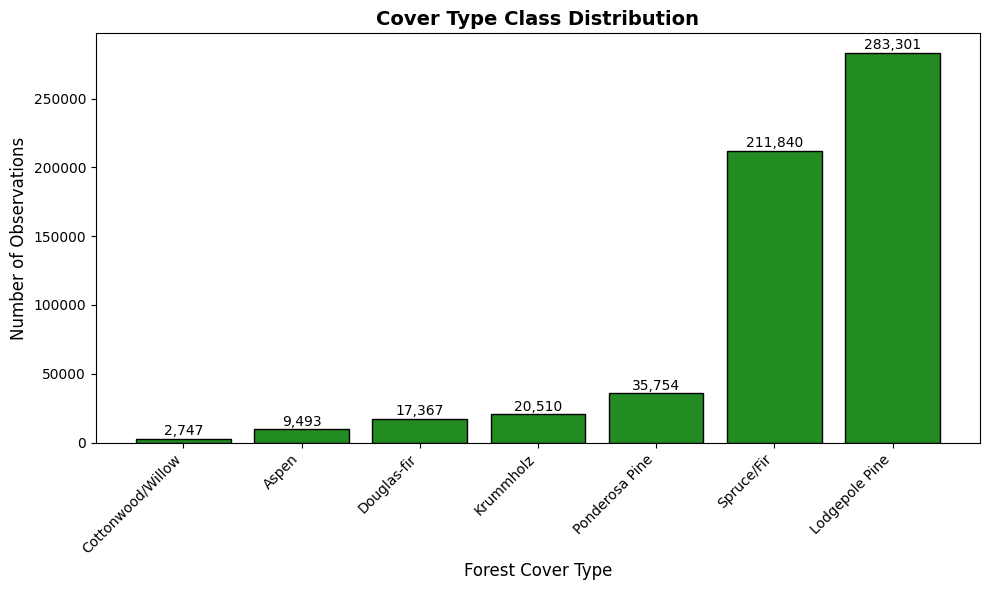

In [26]:
# Covertype Mapping
covertype_class = {
        1: 'Spruce/Fir', 2: 'Lodgepole Pine',
        3: 'Ponderosa Pine', 4: 'Cottonwood/Willow',
        5: 'Aspen', 6: 'Douglas-fir', 7:'Krummholz'
}

df['class_name'] = df['Cover_Type'].map(covertype_class)

class_counts = df['class_name'].value_counts().sort_values(ascending=True)
# Create bar chart
plt.figure(figsize=(10, 6))
plt.bar(class_counts.index, class_counts.values, color='forestgreen', edgecolor='black')

for i, (name, count) in enumerate(zip(class_counts.index, class_counts.values)):
        plt.text(i, count + 500, f'{count:,}', ha='center', va='bottom', fontsize=10)
plt.title('Cover Type Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Forest Cover Type', fontsize=12)
plt.ylabel('Number of Observations', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Treemap Visualization

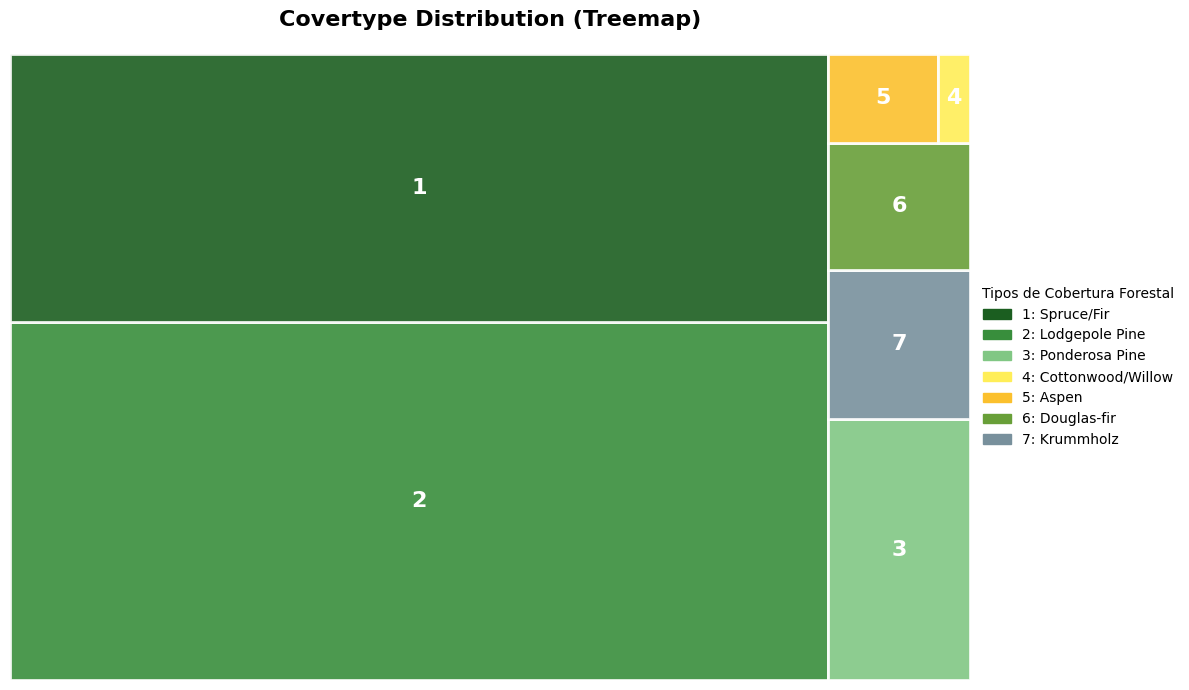

In [27]:
# COLOR MAPPING
custom_colors = {
    1: '#1B5E20', # Spruce/Fir (Verde oscuro denso)
    2: '#388E3C', # Lodgepole Pine (Verde bosque)
    3: '#81C784', # Ponderosa Pine (Verde claro)
    4: '#FFEE58', # Cottonwood/Willow (Amarillo sauce)
    5: '#FBC02D', # Aspen (Amarillo otoñal)
    6: '#689F38', # Douglas-fir (Verde oliva)
    7: '#78909C'  # Krummholz (Grisáceo/Alta montaña)
}

# COUNTS PER CLASS
counts = df['Cover_Type'].value_counts().sort_values(ascending=False)

# LABELS AND COLORS
labels = [str(idx) for idx in counts.index]
color_list = [custom_colors[idx] for idx in counts.index]


plt.figure(figsize=(12, 7))

squarify.plot(
    sizes=counts.values, 
    label=labels, 
    color=color_list,
    alpha=0.9, 
    edgecolor="white", 
    linewidth=2,
    text_kwargs={'fontsize': 16, 'weight': 'bold', 'color': 'white'}
)

# LEGEND
legend_handles = [
    mpatches.Patch(color=custom_colors[i], label=f"{i}: {covertype_class[i]}") 
    for i in sorted(covertype_class.keys())
]

plt.legend(
    handles=legend_handles, 
    title="Tipos de Cobertura Forestal", 
    loc='center left', 
    bbox_to_anchor=(1, 0.5),
    frameon=False
)

plt.title('Covertype Distribution (Treemap)',fontsize=16, fontweight='bold', pad=20)
plt.axis('off')

plt.tight_layout()
plt.show()

## MISSING DATA

In [28]:
print(df.isnull().sum())

Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type11                           0


There is no missing data.

## Train vs Test Samples

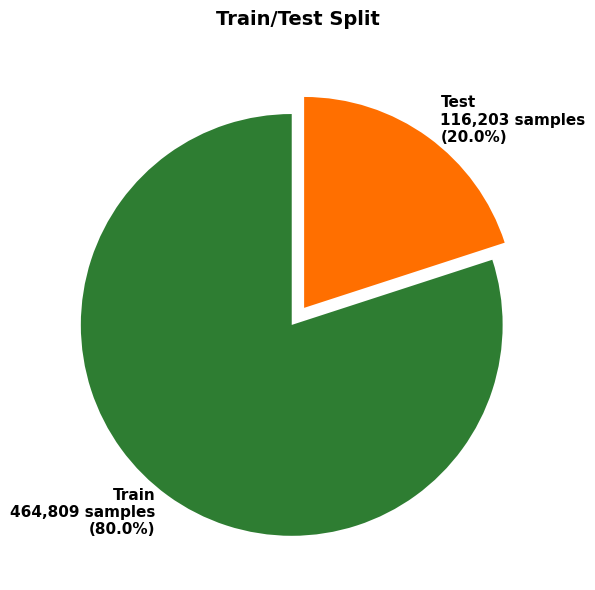

Total Samples: 581,012
Train Samples: 464,809 (80.0%)
Test Samples: 116,203 (20.0%)


In [29]:
TEST_SIZE = 0.2
RANDOM_STATE = 42

# Total Samples
total_samples = len(df)

# Calculate train/test split
X = df.drop(['Cover_Type', 'class_name'], axis=1)
y = df['Cover_Type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

train_samples = len(X_train)
test_samples = len(X_test)

# VISUALIZATION - Train/Test Split
plt.figure(figsize=(8, 6))

sizes = [train_samples, test_samples]
labels = [f'Train\n{train_samples:,} samples\n({train_samples/total_samples*100:.1f}%)', 
          f'Test\n{test_samples:,} samples\n({test_samples/total_samples*100:.1f}%)']
colors = ['#2E7D32', '#FF6F00']
explode = (0.05, 0.05)

plt.pie(sizes, labels=labels, colors=colors, autopct='', startangle=90, 
        explode=explode, textprops={'fontsize': 11, 'weight': 'bold'})
plt.title('Train/Test Split', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Print summary
print(f"Total Samples: {total_samples:,}")
print(f"Train Samples: {train_samples:,} ({train_samples/total_samples*100:.1f}%)")
print(f"Test Samples: {test_samples:,} ({test_samples/total_samples*100:.1f}%)")


## Feature Distribution

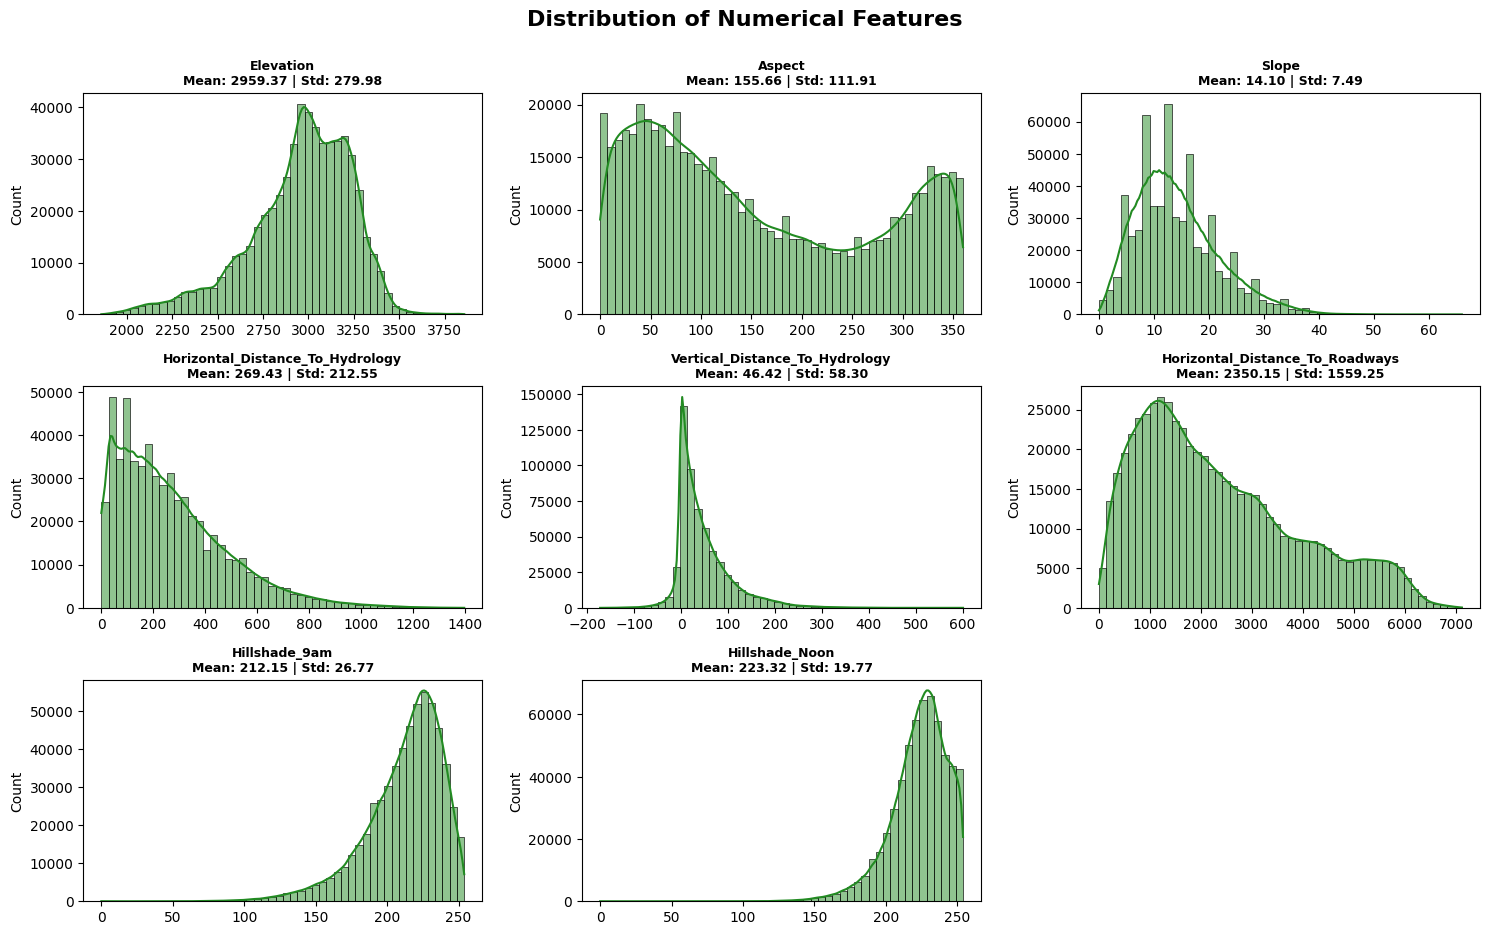

In [30]:
numerical_features = ['Elevation', 'Aspect', 'Slope', 
                      'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 
                      'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon']

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(numerical_features):
    sns.histplot(df[col], bins=50, kde=True, color='forestgreen', ax=axes[idx])
    axes[idx].set_title(f'{col}\nMean: {df[col].mean():.2f} | Std: {df[col].std():.2f}', 
                       fontsize=9, fontweight='bold')
    axes[idx].set_xlabel('')

for idx in range(len(numerical_features), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


The distribution of some of the numerical features of the dataset presents skewness. For example Hillshade_9am and Hillshade_Noon are completely right-skewed. In addition, we find less extreme right skewness in elevation and left skewness in slope, Vertical_Distance_To_Hydrology and Horizontal_Distance_To_Hydrology.

It is interesting to correct skewness and make features follow a normal distribution. This way, models will likely be better.

## Outlier Analysis - Boxplot

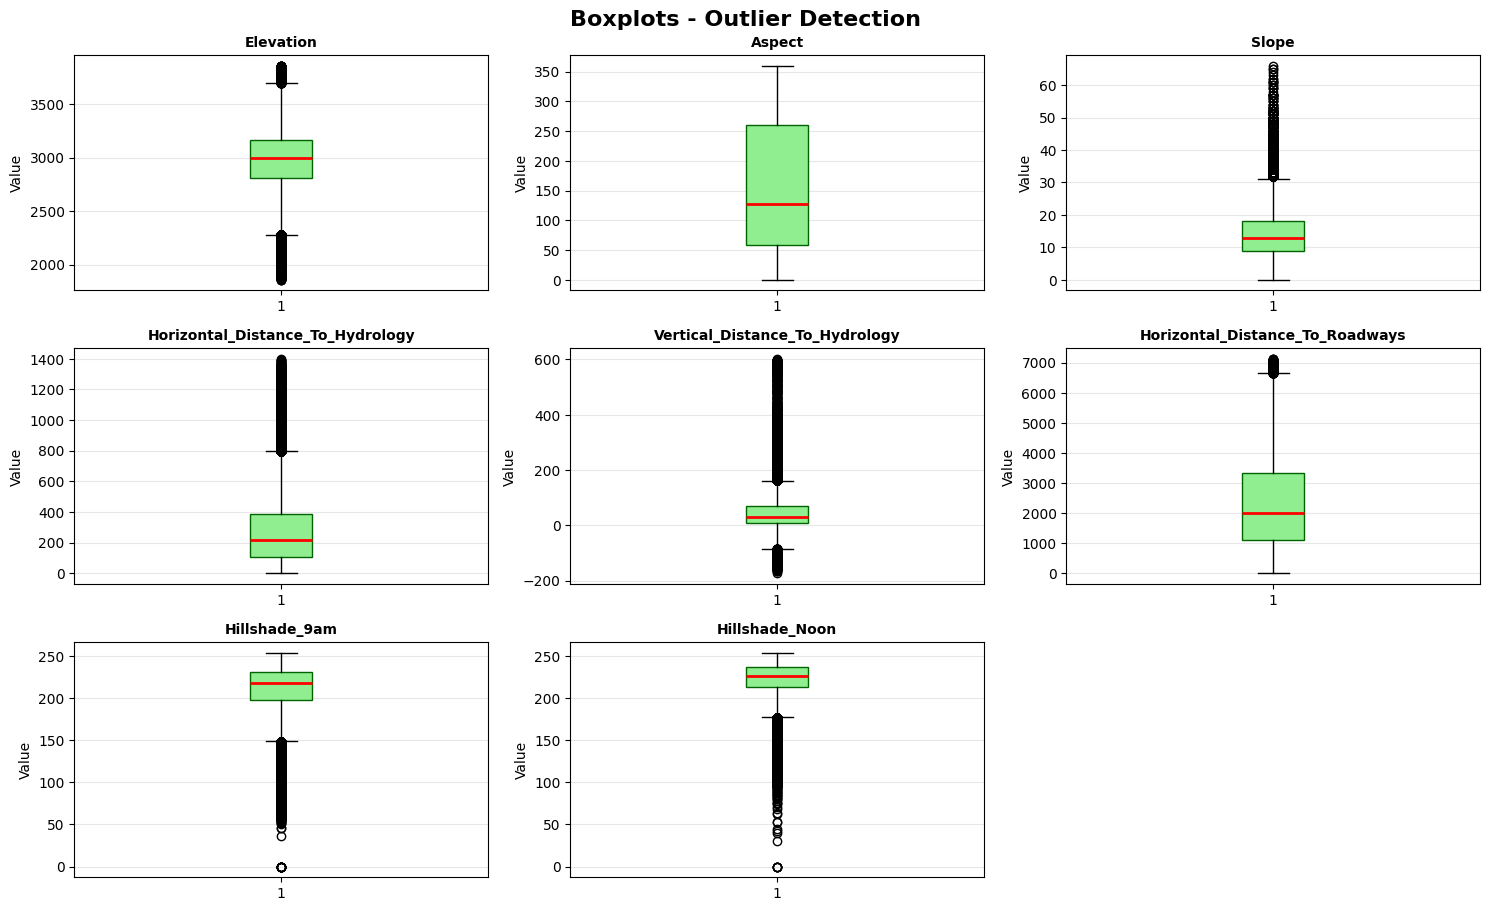

In [31]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(numerical_features):
    axes[idx].boxplot(df[col], vert=True, patch_artist=True,
                     boxprops=dict(facecolor='lightgreen', color='darkgreen'),
                     medianprops=dict(color='red', linewidth=2))
    axes[idx].set_title(f'{col}', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(axis='y', alpha=0.3)

for idx in range(len(numerical_features), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Boxplots - Outlier Detection', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In this boxplots, we find that every numerical feature except from aspect has outliers. We will correct this in data preprocessing.

## Distribution of Numerical Features By Covertype

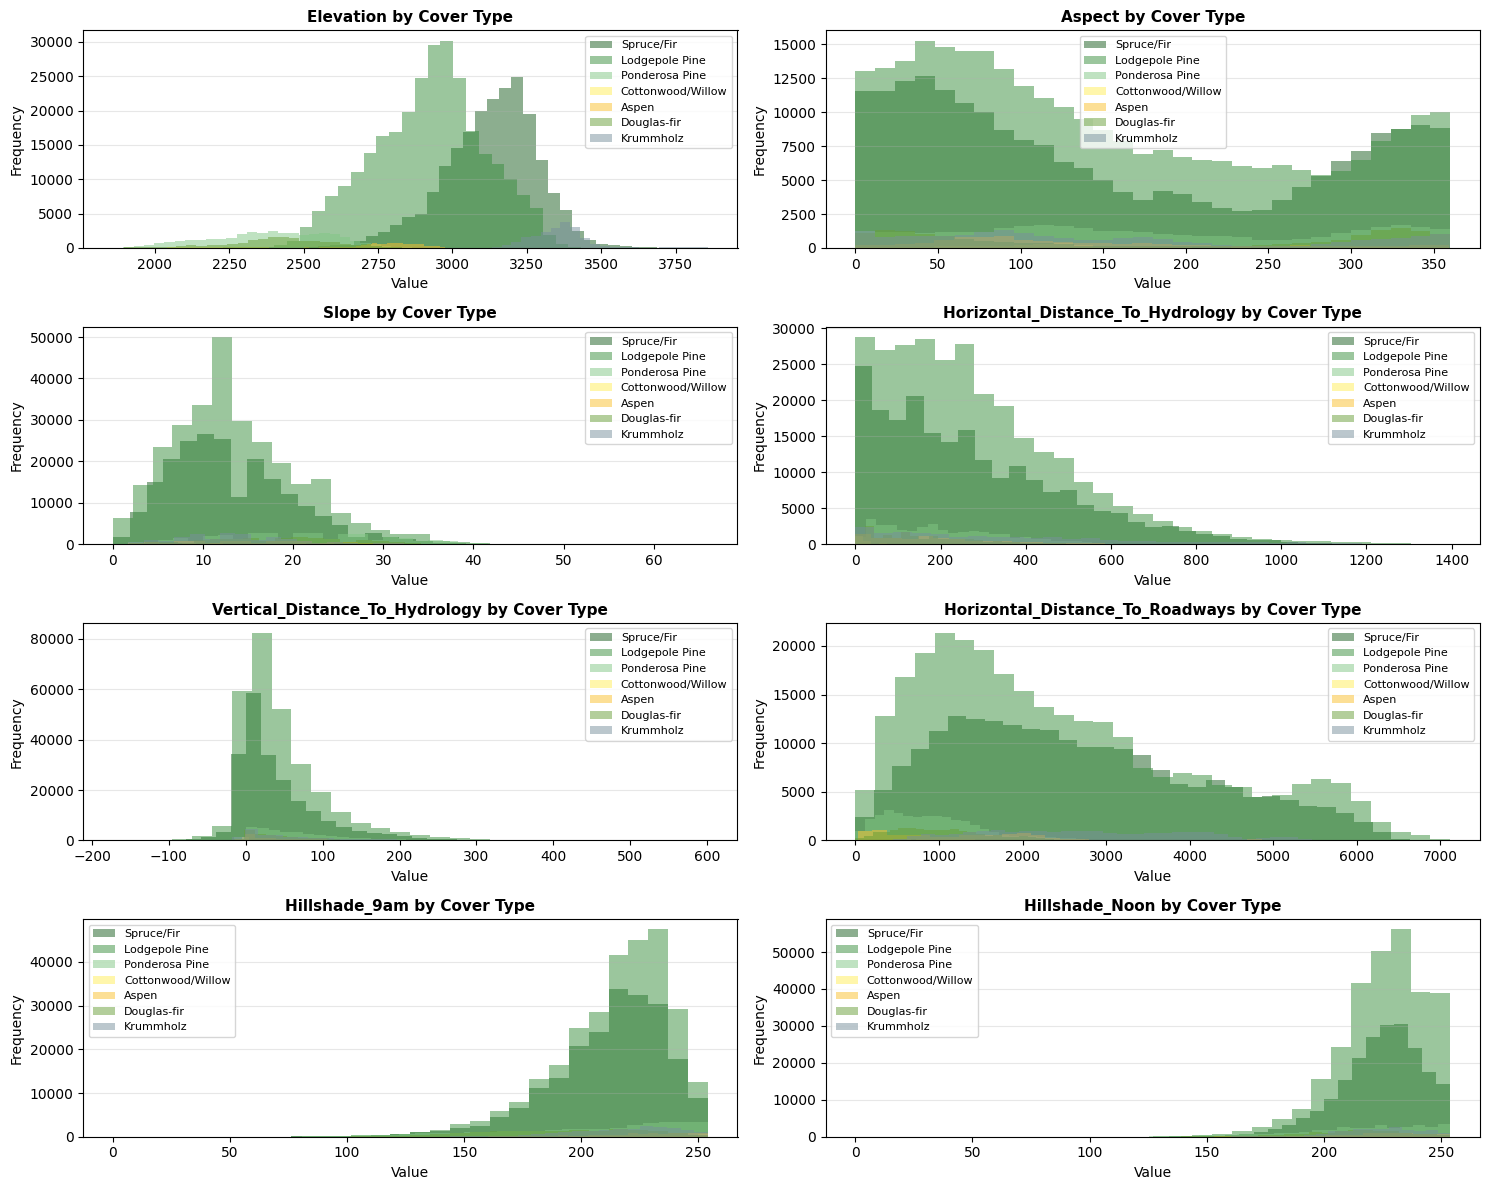

In [36]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(15, 12))
axes = axes.flatten()

for idx, col in enumerate(numerical_features):
    for cover_type in sorted(df['Cover_Type'].unique()):
        subset = df[df['Cover_Type'] == cover_type]
        axes[idx].hist(subset[col], bins=30, alpha=0.5, 
                      label=covertype_class[cover_type], 
                      color=custom_colors[cover_type])
    
    axes[idx].set_title(f'{col} by Cover Type', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()